# BEE 4750 Homework 3: Discretization, Numerical Convergence, and

Simulation

**Name**: Gina Chen, Mikael Murphy-Rendon

**ID**: cc2859, mm3446

> **Due Date**
>
> Thursday, 09/24/26, 9:00pm

## Overview

### Instructions

- Problem 1 asks you to discretize several systems models by hand and
  reason about characteristic timescales and convergence, without
  writing any code.
- Problem 2 asks you to extend the shallow lake model from class to
  include a sediment phosphorus stock, then use numerical simulation to
  check convergence and study the resulting long-term lake dynamics.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Desktop/BEE 4750/hw03`


In [2]:
using Plots
using LaTeXStrings

## Problems (Total: 50 Points)

### Problem 1 (15)

For each of the following systems models, (i) write the forward Euler
update rule, (ii) find the (local) characteristic timescale and use it
to evaluate whether the given step size $\Delta t$ is a reasonable
choice, and (iii) use the given error to predict the error at the new
step size, assuming the method is well into its first-order convergence
regime.

#### Problem 1.1 (4) 


$$\frac{dC}{dt} = 5 - 0.25C$$

1.  Write the forward Euler update rule for $C(t + \Delta t)$.

2.  Find the characteristic timescale of this system. Is $\Delta t = 1$
    a reasonable starting choice of step size? Justify your answer.

3.  A forward Euler simulation of this system has an error of $0.6$ at
    $\Delta t = 2$. What error would you expect at $\Delta t = 1$?

#### Answer to Problem 1.1
<img align="right" src="Answer to Problem 1.1.jpeg" />

#### Problem 1.2 (5)

A well-mixed holding tank has volume $V = 200\ \text{m}^3$ and a
through-flow of $Q = 50\ \text{m}^3/\text{yr}$ carrying an inflow
concentration $C_\text{in} = 2\ \text{mg/L}$. A pollutant in the tank
also decays at a first-order rate $k = 0.3\ \text{yr}^{-1}$. The
concentration in the tank, $C(t)$, is governed by

$$\frac{dC}{dt} = \frac{Q}{V}\left(C_\text{in} - C\right) - kC.$$

1.  Write the forward Euler update rule for $C(t + \Delta t)$.

2.  Find the characteristic timescale of this system. Is
    $\Delta t = 1\ \text{yr}$ a reasonable starting choice of step size?
    Justify your answer.

3.  A forward Euler simulation of this system has an error of $0.8$ at
    $\Delta t = 1.6\ \text{yr}$. What error would you expect at
    $\Delta t = 0.4\ \text{yr}$?

#### Answer to Problem 1.2
<img align="right" src="images/Problem1.2.jpeg" />

#### Problem 1.3 (6)


$$\frac{dx}{dt} = 3 - 0.5x^2, \qquad x \geq 0$$

1.  Write the forward Euler update rule for $x(t + \Delta t)$.

2.  This system’s rate of change depends on the state $x$, so there is
    no single characteristic timescale for the whole system — only a
    *local* one. Find the system’s equilibrium (be careful about the
    problem domain), then linearize near it to find the local feedback
    gain and the local characteristic timescale there. Is
    $\Delta t = 0.5$ a reasonable starting choice of step size near this
    equilibrium? Justify your answer.

3.  A forward Euler simulation of this system has an error of $1.5$ at
    $\Delta t = 0.3$. What error would you expect at $\Delta t = 0.1$?

#### Answer to Problem 1.3
<img align="right" src="images/Problem1.3.jpeg" />

### Problem 2 (35)

In class, we modeled a shallow lake’s phosphorus (P) concentration with

$$\frac{dP}{dt} = L - sP + R(P),$$

treating the maximum sediment release rate $r$ (inside $R(P)$) as a
fixed constant. A more advanced version of this model could be built by
noting that $r$ is really $\kappa M$, where $M$ is a **sediment
phosphorus pool** — a slowly-filling stock.

The two-stock model splits the single loss rate $s$ into two pieces
(outflow/permanent burial, $s_\text{out}$, and transfer into the
sediment, $h$), and adds a second state variable $M(t)$ for the sediment
pool:

$$\begin{aligned}
\frac{dP}{dt} &= L - s_\text{out}P - hP + \kappa M\,\frac{P^q}{m^q + P^q} \\[0.3em]
\frac{dM}{dt} &= hP - bM - \kappa M\,\frac{P^q}{m^q + P^q}
\end{aligned}$$

where $b$ is the rate at which sediment P is permanently buried. Use the
parameter values in
<a href="#tbl-lake-params" class="quarto-xref">Table 1</a> for the rest
of this problem.

| Parameter | Meaning | Value |
|:------------------------:|:--------------------|:------------------------:|
| $s_\text{out}$ | P outflow/permanent burial rate (from the water column) | $0.3\ \text{yr}^{-1}$ |
| $h$ | P transfer rate into the sediment | $0.3\ \text{yr}^{-1}$ |
| $b$ | sediment P burial rate | $0.02\ \text{yr}^{-1}$ |
| $\kappa$ | sediment recycling rate coefficient | $0.15\ \text{yr}^{-1}$ |
| $m$ | P concentration at half-maximum sediment release | $25\ \mu\text{g}/\text{L}$ |
| $q$ | steepness of the sediment release response | $8$ |

Table 1: Parameters for the two-stock lake model.

Assume the lake starts with no phosphorus anywhere in the system,
$P(0) = M(0) = 0$.

#### Problem 2.1 (5)


Derive the forward Euler update rules for $P(t+\Delta t)$ and
$M(t + \Delta t)$. Note that these two updates are coupled: at each
step, both updates use the *current* $P(t)$ and $M(t)$ (not the
newly-updated value of one when computing the other).

#### Answer to Problem 2.1
<img align="right" src="Answer to 2.1.jpeg" />

#### Problem 2.2 (13)

Implement your update rules from Problem 2.1 and use them to simulate
the lake under a loading of
$L = 10\ \mu\text{g}/(\text{L}\cdot\text{yr})$, starting from
$P(0) = M(0) = 0$.

Two different quantities have to be “large enough” here, for two
different reasons:

- the **simulation horizon** $T$ has to be long enough for the slow
  sediment stock $M$ to fill. Its characteristic timescale is
  $1/b = 1/0.02 = 50\ \text{yr}$, so use $T = 300\ \text{yr}$ — six of
  those timescales. You will reuse this same run in Problem 2.3.
- the **step size** $\Delta t$ is what you are actually checking for
  numerical convergence, at that fixed $T$.

Run a convergence study on $P(30)$, the phosphorus concentration thirty
years in. Build a reference solution at a very fine step size (smaller
than you think you might need), then test a sequence of
successively-halved, coarser step sizes against it. Here is a starting
point:

``` julia
function simulate_lake(loading, horizon, step)
  
    # TODO: forward Euler on P and M, using your update rules from Problem 2.1.
    # Both updates use the *current* P and M, not a partly-updated value.
    # Return the full P trajectory as a vector, one entry per step taken.
    #error("simulate_lake has not been written yet -- replace this line with your loop")
 
step_reference = 0.001                        # 300,000 steps at T = 300; a few seconds
P_reference = simulate_lake(10.0, 300.0, step_reference)
P30_reference = P_reference[Int(30 / step_reference)]     # the entry at t = 30 yr
```

Report a table of your step sizes, the resulting $P(30)$, the error
relative to your reference, and the empirical order of convergence
between successive refinements. Make a log-log plot of error
vs. $\Delta t$, and state which step size you will use for the rest of
this problem and why.

> **A step size that is too large will not just be inaccurate**
>
> Forward Euler can blow up entirely, rather than merely losing
> accuracy, when the step is too large for the *fastest* process in the
> system. Here that is $P$ itself, with a timescale of
> $1/(s_\text{out} + h) \approx 1.7\ \text{yr}$ — much faster than the
> sediment pool that set $T$. **The horizon is governed by the slowest
> process; the step size is governed by the fastest one.**
>
> Start your sequence at $\Delta t = 2\ \text{yr}$ and halve from there.
> If you try something much coarser you may see the simulation diverge
> or oscillate wildly; that is worth a sentence, but it is not what the
> convergence study is measuring.

   Resolving package versions...
  No Changes to `~/Desktop/BEE 4750/hw03/Project.toml`
  No Changes to `~/Desktop/BEE 4750/hw03/Manifest.toml`


┌───────────┬─────────┬────────────┬──────────────────────┐
│ Step size │   P(30) │      Error │ Order of convergence │
├───────────┼─────────┼────────────┼──────────────────────┤
│       2.0 │ 18.3681 │   0.216562 │                  N/A │
│       1.0 │ 18.4709 │   0.113701 │                 0.93 │
│       0.5 │ 18.5264 │   0.058195 │                 0.97 │
│      0.25 │ 18.5552 │  0.0294078 │                 0.98 │
│     0.125 │ 18.5699 │  0.0147393 │                  1.0 │
│    0.0625 │ 18.5773 │ 0.00733398 │                 1.01 │
│   0.03125 │  18.581 │ 0.00361325 │                 1.02 │
└───────────┴─────────┴────────────┴──────────────────────┘


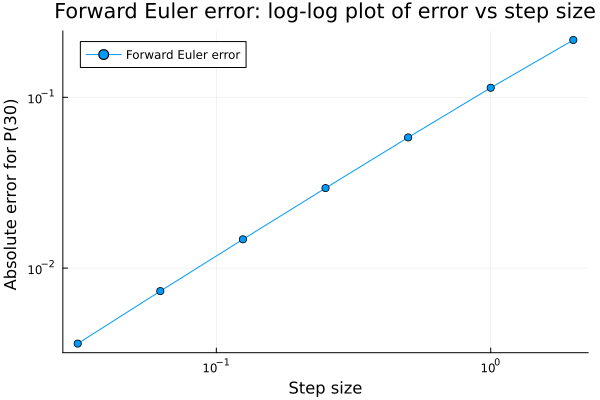

In [8]:

function simulate_lake(loading, horizon, step)
  # Loading = L, horizon = T = end point (year, or some time), step = delta t
    # TODO: forward Euler on P and M, using your update rules from Problem 2.1.
    # Both updates use the *current* P and M, not a partly-updated value.
    # Return the full P trajectory as a vector, one entry per step taken.
    #error("simulate_lake has not been written yet -- replace this line with your loop")
  s_out = 0.3 
  h = 0.3
  b = 0.02
  k = 0.15
  m = 25
  q = 8 
  time = 0:step:horizon 
  P0 = 0 
  M0 = 0 

  P_simulate = zeros(length(time)) # Array to store x number of results, x = length depneding on step size and end/horizon 
  P = P0 
  M = M0 

  for i in 1:length(time)
    P_simulate[i] = P
    if i < length(time) # To continue reiterating until reaching the end point 
      dP = loading - s_out*P - h*P + k*M*((P^q)/((m^q)+(P^q)))
      dM = h*P - b*M - k*M*((P^q)/((m^q)+(P^q)))
      P = P + step*dP 
      M = M + step*dM
    end 
  end

  return P_simulate

end

# Given
step_reference = 0.001          # 300,000 steps at T = 300; a few seconds
P_reference = simulate_lake(10.0, 300.0, step_reference)
P30_reference = P_reference[Int(30 / step_reference)]     # the entry at t = 30 yr
loading = 10
horizon = 300 

# Convergence study 
delta_t_s = [2, 1, 0.5, 0.25, 0.125, 0.0625, 0.03125]
dt = zeros(length(delta_t_s))
P30 = zeros(length(delta_t_s))
errors = zeros(length(delta_t_s))

orders = fill("N/A", length(delta_t_s)) # Intitial array to store empirical order of convergence

for i in 1:length(delta_t_s)
    dt[i] = delta_t_s[i]
    P_result = simulate_lake(loading, horizon, dt[i])
    
    idx_30 = Int(30 / dt[i]) 
    P30[i] = P_result[idx_30]
    errors[i] = abs(P30[i] - P30_reference)
    
    # Compute empirical order of convergence 
    if i >1 
        p = log2(errors[i-1] / errors[i])
        orders[i] = string(round(p, digits=2))
    end
end




# Build the table 
import Pkg; Pkg.add("PrettyTables")
using PrettyTables


pretty_table(
    (Dt = dt, P30 = P30, AbsError = errors, Order = orders);
    column_labels = ["Step size", "P(30)", "Error", "Order of convergence"] # step sizes, the resulting , the error relative to your reference, and the empirical order of convergence
)


# Plot log log 

plot(dt, errors, 
    xaxis = :log10, yaxis = :log10,
    marker = :circle, 
    label = "Forward Euler error",
    xlabel = "Step size", 
    ylabel = "Absolute error for P(30) ",
    title = "Forward Euler error: log-log plot of error vs step size"
)

**Since the characteristic timescle of about 1.7 from 1/(s_out + h) for this problem, the given starting step size of 2 would blow up. This is because the step size is greater than the charactertistic timescale, leading to the inaccurate approximation for the slope of the function P . Thus, instead of converging, the resulting values of P and M overshoot on each step and the error compounds, which results in  oscillation (if overshoot one direction and then the other) or divergence (if leads to a really large value).**

**Based on the convergence study result in the table, the step size we will use for the rest of this problem is <i>0.125</i>.**
 
**This is because at step size of 0.125, the order of convergence is exactly 1.0, which is the correct order of convergence we are expecting for the Froward Euler, as opposed to too small (such as 0.98) or too large (like 1.01) of order of convergence at any larger or smaller step sizes. Also, the absolute error at this step size is small enough, compared to the P(30) value of 18.5699. If we choose an even smaller step size, the simulation time might be much longer while the error also does not drop too significantly.**


#### Problem 2.3 (10)
Using the step size you justified in Problem 2.2, plot $P(t)$ over the
full 300-year simulation.

You already have $P(30)$ from Problem 2.2. What does $P$ look like once
the simulation has fully run? What is happening physically to the lake
between those two points in time, and around when does it happen?

#### Problem 2.3 Answer
In the graph, 0\<t\<45, the graph resembles a cubic function, wtih one infleciton point around P(t=30). After P(t=45), the function appears to experience exponential decay until it reaches the lake's carrying capacity.

From years 0 to 30, phosphorus is loaded from external sources, and part of that phosphorus is settled into the lake's sediment. M, the sediment stock, accumulates during this time without affecting the water body's total level of phophorus. When the lake reaches the phosphorus threshold of m = 25µg/L the recycling term becomes active, the rational term rises steeply. At this point, M is no longer a sink for phosphorus, but a source into the water. As such, after t=30 years, there is a dramatic increase of phosphorus into the water which acts like a delayed pulse due to the nature of the sediment sink. After t=45 years, internal recycling is dominated by phosphorus burial and outflow, so the P level down to the carrying capacity of the event.

The code below graphs the phosphorus across 300 years and highlights the infllection point at P(30) where sediment from the stock M is intorduced to the water body as well as P(45) where P reaches its peak.

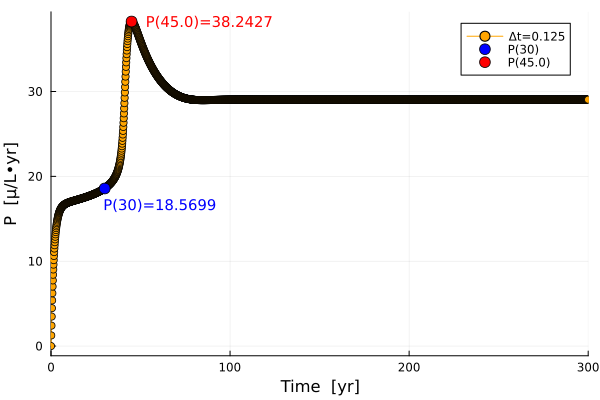

In [4]:
t=0.125
ts=0:t:horizon
P=simulate_lake(loading,horizon,t)
peak=maximum(P)
t_peak = ts[argmax(P)]
label = "   P(" * string(round(t_peak, digits=2)) * ")=" * string(round(peak, digits=4))

plot_P= plot(xlabel="Time  [yr]", ylabel="P  [μ/L•yr]", legend=:topright, xlims=(0, 300))

plot!(plot_P,ts,P,
    color=:orange,markershape=:circle,markersize=4,label="Δt=0.125")
scatter!([30], [18.5699], color=:blue,markersize=6,label="P(30)")
annotate!(30, P30[5], text("\n\nP(30)=18.5699", :blue, :left, 10))
scatter!([t_peak], [peak], color=:red,markersize=6,label="P(" * string(round(t_peak, digits=2))*")")
annotate!(t_peak, peak, text(label, :red, :left, 10))

#### Problem 2.4 (7)

Suppose a lake manager instead used a simpler one-stock model that
ignores the sediment pool entirely (as if $\kappa = 0$, so there is no
recycling at all):

$$\frac{dP}{dt} = L - s_\text{out}P - hP.$$

What is this simplified model’s equilibrium $P$ at
$L = 10\ \mu\text{g}/(\text{L}\cdot\text{yr})$, and would the manager
have concluded the lake is safely oligotrophic at this loading (recall
that sediment release becomes significant once $P$ approaches
$m = 25\ \mu\text{g}/\text{L}$)?

Compare this to what you found in Problem 2.3. What does this tell you
about the risk of using a simplified model, or a short simulation, to
set a “safe” loading level? What would you recommend a lake manager do
differently, given what you now know about this system?


#### Answer to Problem 2.4
<img align="right" src="Answer to P2.4.jpeg" />

While the manager would conclude that the lake is safely oligotrophic, it's important to note that P = 16.6667 is actually very close to the inflection point at P(30) = 18.5699, where the sediment P recycling would take off and lead to a spike in P level. 

Based on our understanding of the lake system, the phosphorus levels in the sediment (modeled by the M pool) do not impact the water's phosphorus concentration until many years into the simulation, making it easy to neglect their contribution to the lake's P concentrations. In reality, the M pool will add a large quantity of P rapidly when the pool reaches capacaity, and this will overwhelm the lake's recycling system to the point that the lake reaches a eutrophic level. From this, we see that using a simplified model or a short simulation neglects additional external forcings that contribute to the P concentration to a high extent at a delay. Setting the "safe" loading level based on a simple or short model/simulation will not actually adhere to the oligotrophic/eutrophic boundary of the lake, and the manager might even face regulatory issues about lack of compliance due to this. We recommend considering the phosphorus sediment pool and overall feedback loop in any simulation since it is a known contribution to the P concentration.

## References

List any external references consulted, including classmates.
- For 1.2, used ENGRD3200 class notes
- For 1.2, referenced this stackexchange thread (https://math.stackexchange.com/questions/1266124/finding-the-characteristic-timescale-of-a-first-order-nonlinear-ode)
- For 1.3, used ENGRD3200 class notes
- Used lecture notes and ENGRD 3200 knowledge for Problem 1.1 and 2.1 setup
- https://discourse.julialang.org/t/ann-prettytables-jl-print-formatted-tables-in-julia/19550 and https://ronisbr.github.io/PrettyTables.jl/v0.3/man/examples/ and https://juliapackages.com/p/prettytables Reference for table in Problem 2.2 
- https://docs.juliaplots.org/dev/tutorial/  reference for log log plot for Problem 2.2
- For 2.3, referenced site for plotting https://github.com/sswatson/cheatsheets/blob/master/plotsjl-cheatsheet.pdf